In [73]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from prophet.serialize import model_to_json, model_from_json

df = pd.read_csv("../data/processed/cleaned_data.csv")

In [61]:
#creating daily sales
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Date"] = df["InvoiceDate"].dt.date

sales = df.groupby(pd.Grouper(key="InvoiceDate", freq="W"))["TotalPrice"].sum().reset_index()

sales.columns = ["ds", "y"]
sales["ds"] = pd.to_datetime(sales["ds"])

In [62]:
train = sales.iloc[:-30]
test = sales.iloc[-30:]

In [63]:
Q1 = sales["y"].quantile(0.25)
Q3 = sales["y"].quantile(0.75)
IQR = Q3 - Q1

sales = sales[
    (sales["y"] >= Q1 - 1.5 * IQR) &
    (sales["y"] <= Q3 + 1.5 * IQR)
]

In [77]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.5    
)
model.fit(sales)

04:27:40 - cmdstanpy - INFO - Chain [1] start processing
04:27:40 - cmdstanpy - INFO - Chain [1] done processing


In [65]:
#future 30 days
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast.head()


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-06,106980.449063,111121.063822,137078.829952,106980.449063,106980.449063,17652.044375,17652.044375,17652.044375,-24197.334406,-24197.334406,-24197.334406,41849.378781,41849.378781,41849.378781,0.0,0.0,0.0,124632.493438
1,2009-12-13,106882.473897,86187.991315,111095.333231,106882.473897,106882.473897,-7848.695044,-7848.695044,-7848.695044,-24197.334406,-24197.334406,-24197.334406,16348.639362,16348.639362,16348.639362,0.0,0.0,0.0,99033.778852
2,2009-12-20,106784.498731,53870.731819,78506.381623,106784.498731,106784.498731,-40578.894333,-40578.894333,-40578.894333,-24197.334406,-24197.334406,-24197.334406,-16381.559927,-16381.559927,-16381.559927,0.0,0.0,0.0,66205.604398
3,2009-12-27,106686.523565,26881.705838,50899.884029,106686.523565,106686.523565,-67620.357539,-67620.357539,-67620.357539,-24197.334406,-24197.334406,-24197.334406,-43423.023133,-43423.023133,-43423.023133,0.0,0.0,0.0,39066.166026
4,2010-01-10,106490.573247,29087.328655,53545.501666,106490.573247,106490.573247,-65321.685751,-65321.685751,-65321.685751,-24197.334406,-24197.334406,-24197.334406,-41124.351345,-41124.351345,-41124.351345,0.0,0.0,0.0,41168.887496


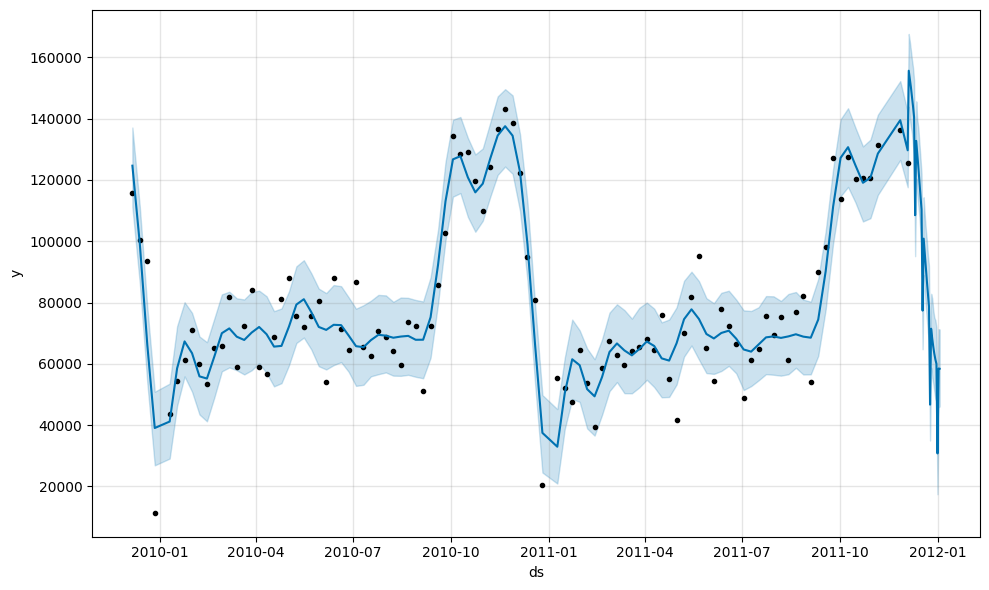

In [66]:
fig1 = model.plot(forecast)

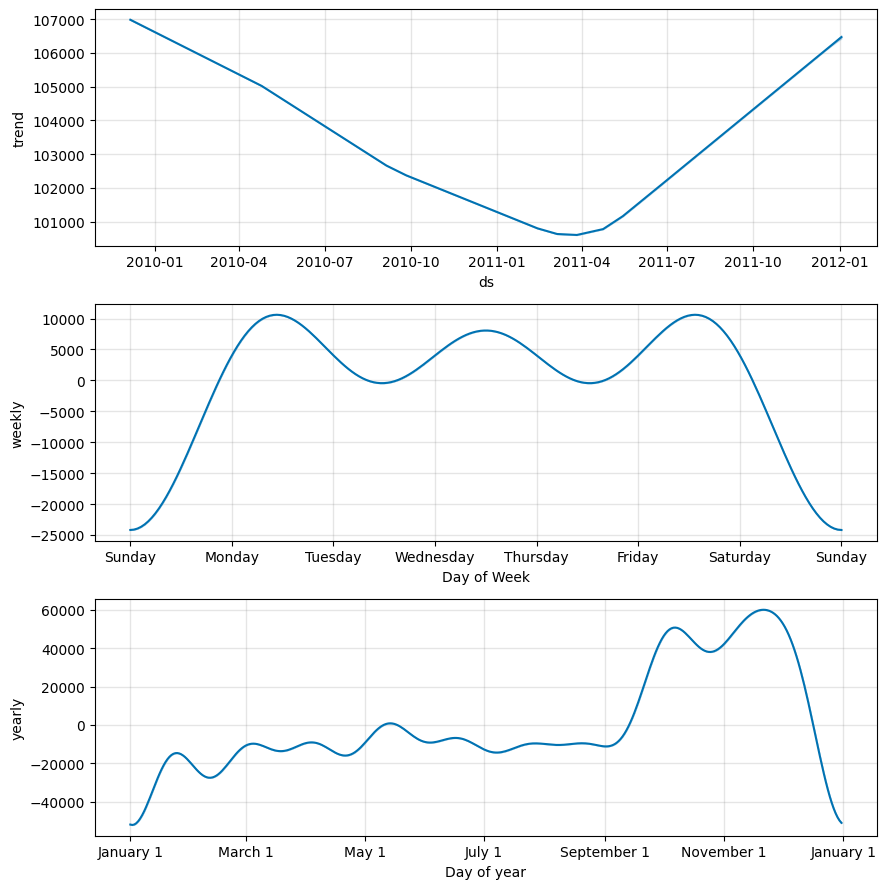

In [67]:
fig2 = model.plot_components(forecast)

In [68]:
forecast_test = forecast[["ds", "yhat"]]

merged = test.merge(forecast_test, on="ds", how="inner")

actual = merged["y"]
pred = merged["yhat"]

In [69]:
mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(((actual - pred) ** 2).mean())

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 7265.87319870189
RMSE: 9215.685625939117


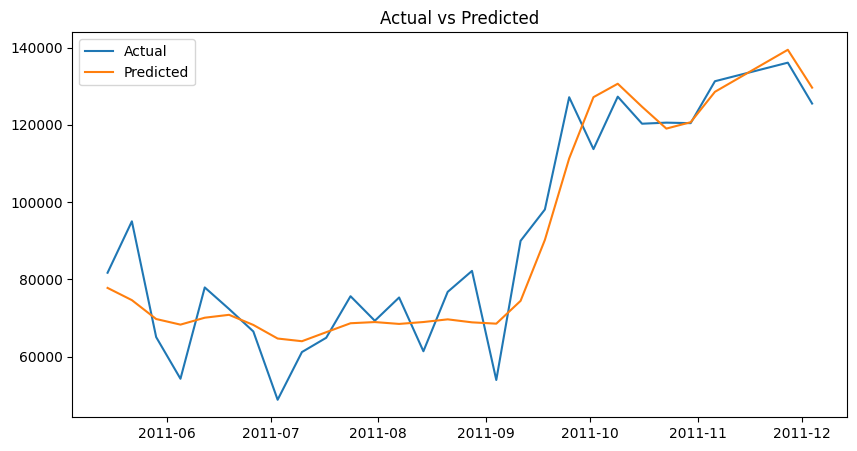

In [70]:
plt.figure(figsize=(10,5))

plt.plot(merged["ds"], merged["y"], label="Actual")
plt.plot(merged["ds"], merged["yhat"], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [76]:
#saving forecast and model
forecast[["ds", "yhat"]].to_csv("../data/processed/forecast.csv", index=False)

with open("../models/prophet_model.json", "w") as f:
    f.write(model_to_json(model))